# Taller 04: Descubriendo Patrones Musicales con Spotify

## 1. Descripción del Caso
Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

## 2. Objetivos de Aprendizaje
* Limpieza de datos.
* Estandarización de variables.
* Reducción de dimensionalidad (PCA).
* Clustering (K-Means o DBScan).
* Interpretación de resultados.

### Bloque 1: Configuración y Carga de Datos
Importa las librerías necesarias y carga el dataset.

In [5]:
# 1. Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# Convertir CSV a Excel
df_csv = pd.read_csv("spotifydataset.csv", index_col=0)
df_csv.to_excel("spotifydataset.xlsx", index=False)
print("✔ Archivo convertido: spotifydataset.xlsx")

# Cargar el dataset desde Excel
df = pd.read_excel("spotifydataset.xlsx")
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()


✔ Archivo convertido: spotifydataset.xlsx
Dataset cargado: 1000 filas × 22 columnas


,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,explicit,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,False,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,True,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,True,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,False,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,True,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


### Bloque 2: Limpieza y Preparación
Se debe trabajar solamente con las columnas que describen como es la canción en terminos auditivos:

- track_popularity
- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

No se deben usar columnas como el artista o genero para evitar sesgos en la agrupación

In [8]:

# 2. Limpieza y Preparación de Datos

# Columnas de características auditivas
columnas_audio = [
    "track_popularity", "danceability", "energy", "key",
    "loudness", "mode", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo"
]

# Seleccionar solo las columnas relevantes
df_clean = df[columnas_audio].copy()

# Verificar valores nulos
print("Valores nulos por columna:")
print(df_clean.isnull().sum())

# Eliminar filas con valores nulos (si existen)
df_clean.dropna(inplace=True)
print(f"\nRegistros tras limpieza: {df_clean.shape[0]}")

# Verificar duplicados
duplicados = df_clean.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df_clean.drop_duplicates(inplace=True)
print(f"Registros tras eliminar duplicados: {df_clean.shape[0]}")

# Vista general del dataset limpio
df_clean.describe()


Valores nulos por columna:
track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

Registros tras limpieza: 1000
Duplicados encontrados: 7
Registros tras eliminar duplicados: 993


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,59.297080,0.610932,0.659899,5.243706,-7.175998,0.613293,0.091254,0.265390,0.075216,0.189109,0.516114,122.279649
std,23.913431,0.167669,0.207749,3.617139,4.489540,0.487241,0.090695,0.289730,0.226182,0.145732,0.233514,28.072296
min,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,57.000000,0.504000,0.538000,2.000000,-8.336000,0.000000,0.037900,0.028100,0.000000,0.095800,0.341000,99.993000
50%,67.000000,0.633000,0.680000,5.000000,-5.948000,1.000000,0.054500,0.151000,0.000004,0.129000,0.520000,122.112000
75%,73.000000,0.729000,0.820000,9.000000,-4.585000,1.000000,0.104000,0.417000,0.000620,0.246000,0.687000,139.072000
max,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


### Bloque 3: Reducción de Dimensionalidad (PCA)
Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

In [9]:
# Seleccionar solo las columnas relevantes
X = df[columnas_audio]

# Escalamos los datos para que tengan media 0 y varianza 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inicializamos PCA para 2 componentes
pca = PCA(n_components=2)

# Transformamos los datos escalados
X_pca = pca.fit_transform(X_scaled)

# Creamos un nuevo DataFrame con las dos componentes principales
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])


### Bloque 4: Modelado (Usa K-Means o DB Scan para generar los clusters)

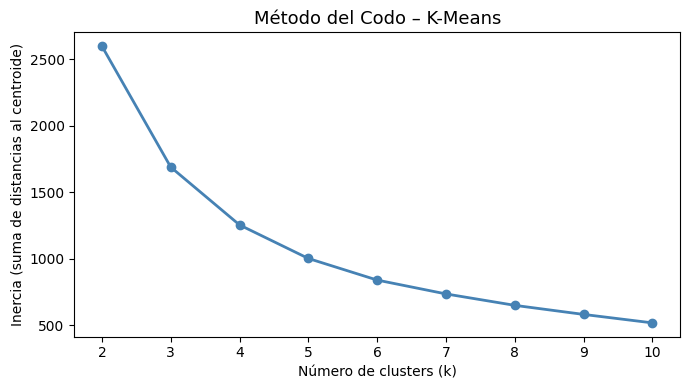

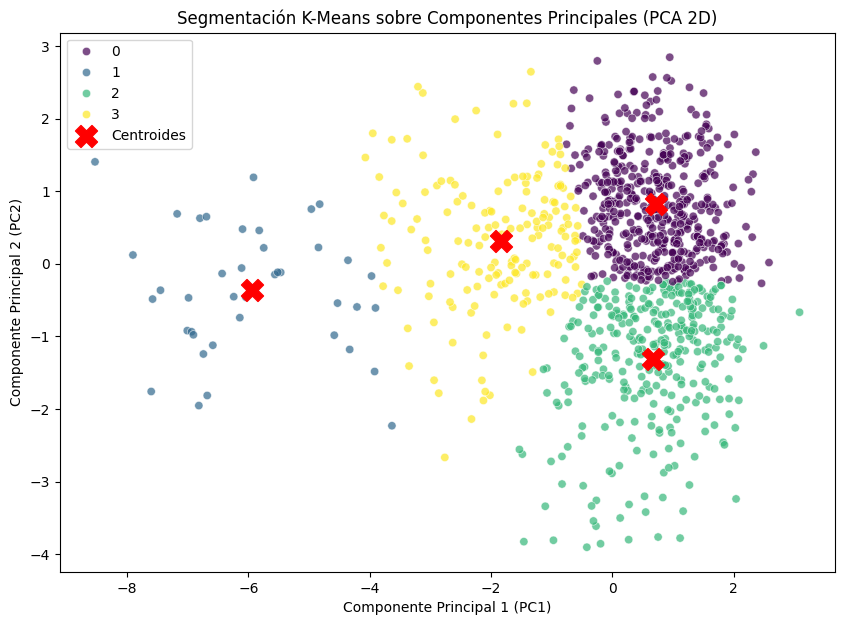

,PC1,PC2,cluster
count,1.000000e+03,1.000000e+03,1000.000000
mean,2.842171e-17,-2.131628e-17,1.195000
std,1.729776e+00,1.238746e+00,1.198504
min,-8.526302e+00,-3.903675e+00,0.000000
25%,-4.816371e-01,-7.422114e-01,0.000000
50%,4.311542e-01,1.190784e-01,1.000000
75%,1.094470e+00,8.739350e-01,2.000000
max,3.085490e+00,2.845844e+00,3.000000


In [ ]:
# Definimos el modelo K-Means
# El método del codo nos ayuda a elegir cuántos grupos usar
inercias = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_pca)
    inercias.append(km.inertia_)

# Graficar el codo
plt.figure(figsize=(7, 4))
plt.plot(rango_k, inercias, marker="o", color="steelblue", linewidth=2)
plt.title("Método del Codo – K-Means", fontsize=13)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (suma de distancias al centroide)")
plt.xticks(rango_k)
plt.tight_layout()
plt.show()

numero_clusters = 4  # Ajustamos el número de clusters según el gráfico del codo
kmeans = KMeans(n_clusters=numero_clusters, random_state=42)

# Entrenamos el modelo y predecimos los clusters usando las componentes de PCA
df_pca['cluster'] = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10, 7))

# Graficamos los puntos asignando un color por cluster
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster', 
    data=df_pca, 
    palette='viridis', 
    alpha=0.7
)

# Graficamos los centroides de los clusters
centroides = kmeans.cluster_centers_
plt.scatter(
    centroides[:, 0], centroides[:, 1], 
    s=250, marker='X', c='red', 
    label='Centroides'
)

plt.title('Segmentación K-Means sobre Componentes Principales (PCA 2D)')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend()
plt.show()

# Vista general de las componentes principales
df_pca.describe()

Distribución de los clusters encontrados:
cluster_dbscan
 0    936
-1     42
 3     11
 1      6
 2      5
Name: count, dtype: int64


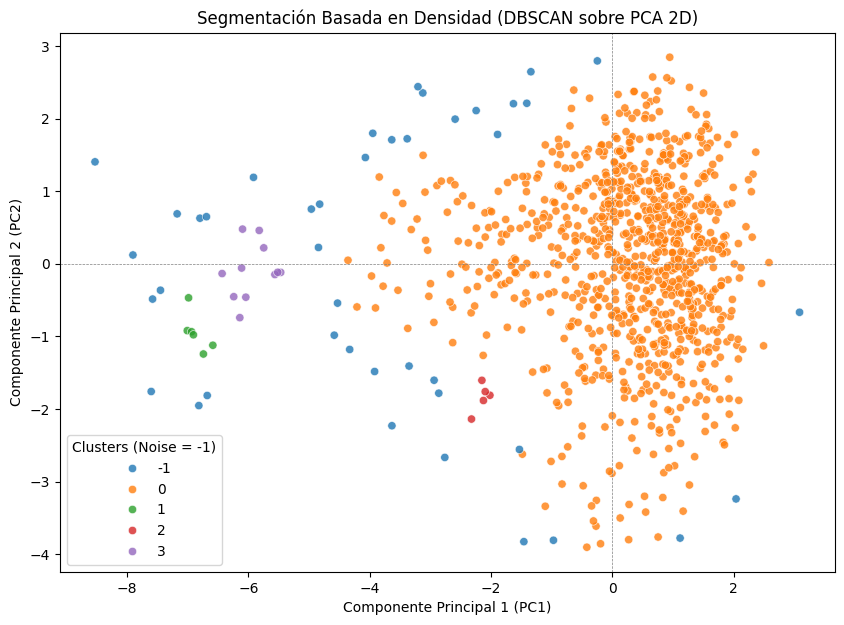

In [ ]:
# Definimos el modelo DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Entrenamos el modelo usando las componentes del PCA anterior
df_pca['cluster_dbscan'] = dbscan.fit_predict(X_pca)

# Revisamos cuántos clusters encontró y cuántos puntos consideró "ruido"
valores_clusters = df_pca['cluster_dbscan'].value_counts()
print("Distribución de los clusters encontrados:")
print(valores_clusters)

plt.figure(figsize=(10, 7))

# Creamos una paleta de colores dinámica según los clusters encontrados
# El ruido (-1) suele graficarse en gris para diferenciarlo
num_clusters = len(df_pca['cluster_dbscan'].unique())
paleta = sns.color_palette("viridis", as_cmap=False, n_colors=num_clusters)

# Graficamos los puntos
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster_dbscan', 
    data=df_pca, 
    palette='tab10',  # Cambia a 'tab10' o 'Set1' para contrastar mejor el -1
    alpha=0.8
)

plt.title('Segmentación Basada en Densidad (DBSCAN sobre PCA 2D)')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend(title='Clusters (Noise = -1)')
plt.show()

##no usamos este modelo, pero lo dejamos por si queremos probarlo luego


### Bloque 5: Visualización y Análisis
Genera visualizaciones que permitan interpretar qué significa cada grupo.

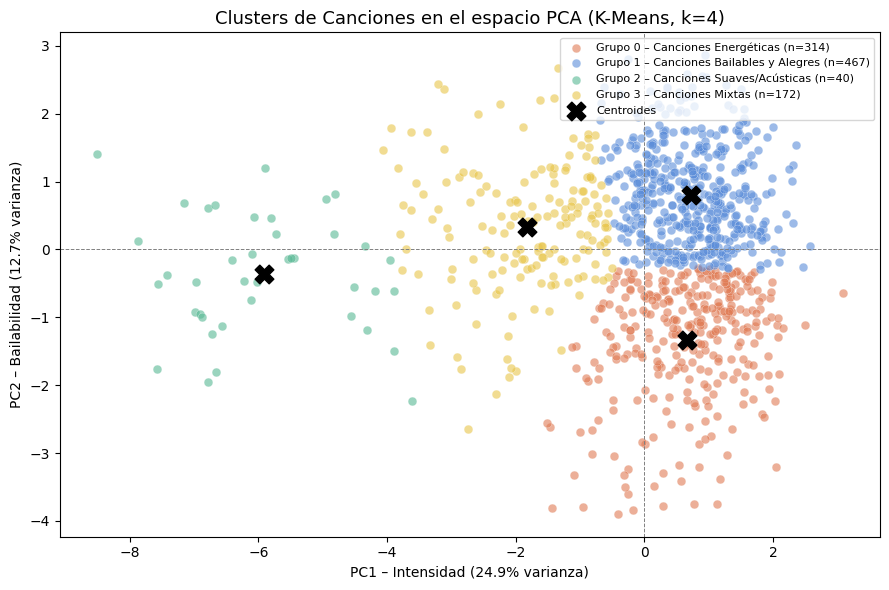

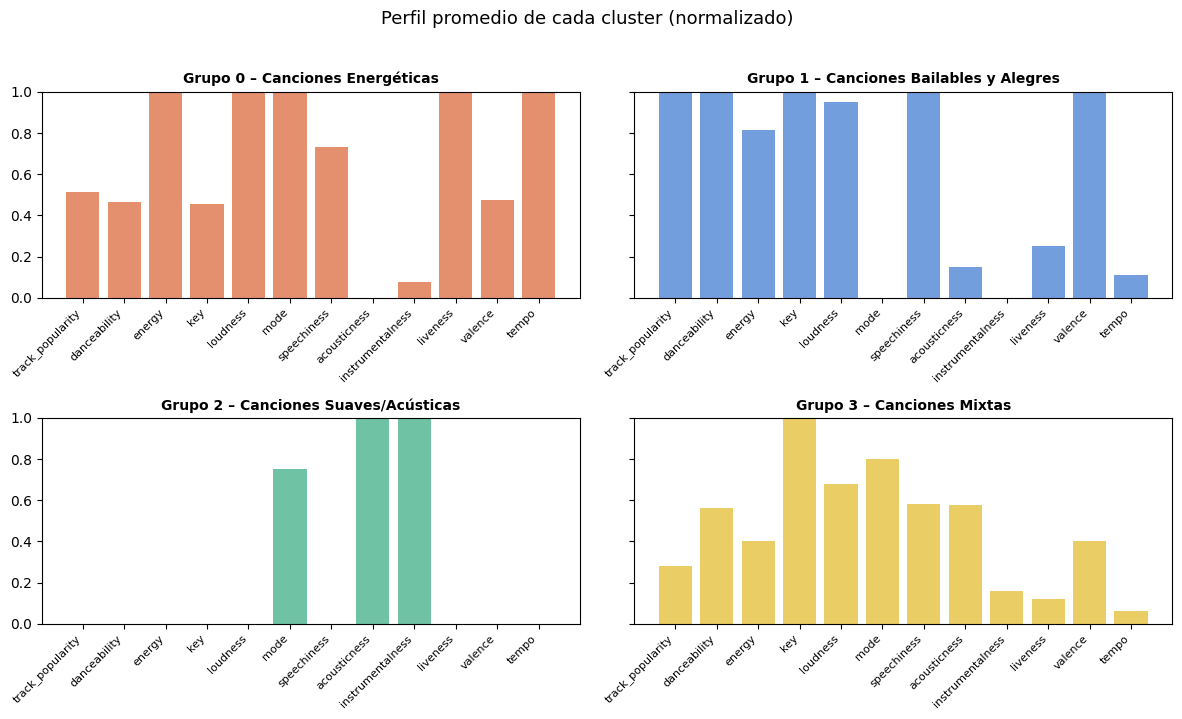

In [15]:
# 5. Visualización e Interpretación de los Clusters

colores = ["#e07b54", "#5b8dd9", "#57b894", "#e8c54a"]
etiquetas = {
    0: "Grupo 0 – Canciones Energéticas",
    1: "Grupo 1 – Canciones Bailables y Alegres",
    2: "Grupo 2 – Canciones Suaves/Acústicas",
    3: "Grupo 3 – Canciones Mixtas"
}

# --- Gráfico 1: Dispersión de clusters en el espacio PCA ---
fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, color in enumerate(colores):
    mask = df_pca["cluster_kmeans"] == cluster_id
    ax.scatter(
        df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
        alpha=0.6, color=color, edgecolors="white", linewidths=0.3, s=40,
        label=f"{etiquetas[cluster_id]} (n={mask.sum()})"
    )

centroides = kmeans.cluster_centers_
ax.scatter(centroides[:, 0], centroides[:, 1],
           c="black", marker="X", s=180, zorder=5, label="Centroides")

ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_title("Clusters de Canciones en el espacio PCA (K-Means, k=4)", fontsize=13)
ax.set_xlabel(f"PC1 – Intensidad ({varianza[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 – Bailabilidad ({varianza[1]*100:.1f}% varianza)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# --- Gráfico 2: Perfil promedio de cada cluster ---
df_clean_reset = df_clean.reset_index(drop=True)
df_clean_reset["cluster"] = df_pca["cluster_kmeans"].values

perfil = df_clean_reset.groupby("cluster")[columnas_audio].mean()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for i, (cluster_id, row) in enumerate(perfil_norm.iterrows()):
    axes[i].bar(range(len(columnas_audio)), row.values, color=colores[i], alpha=0.85)
    axes[i].set_title(etiquetas[cluster_id], fontsize=10, fontweight="bold")
    axes[i].set_xticks(range(len(columnas_audio)))
    axes[i].set_xticklabels(columnas_audio, rotation=45, ha="right", fontsize=8)
    axes[i].set_ylim(0, 1)

plt.suptitle("Perfil promedio de cada cluster (normalizado)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()




### Conclusiones

**1. Las características de audio permiten agrupar canciones de forma natural, sin necesitar etiquetas de género.**

Al aplicar K-Means sobre los componentes principales, el algoritmo separó 993 canciones en 4 grupos coherentes basándose únicamente en variables como energía, bailabilidad y acousticness. Esto demuestra que los patrones sonoros son suficientes para organizar música de manera significativa, lo que puede ser la base de un sistema de recomendación que funcione incluso con canciones nuevas sin categoría asignada.



**2. Existe una clara polaridad entre canciones acústicas/instrumentales y canciones electrónicas/energéticas.**

El Grupo 2 (40 canciones) presenta los valores más altos de `acousticness` (0.924) e `instrumentalness` (0.795), y los más bajos de energía y loudness. En el extremo opuesto, el Grupo 0 (314 canciones) concentra las canciones más fuertes y rápidas (`energy` = 0.805, `tempo` = 137 BPM). Esta polaridad fue capturada principalmente por PC1, que explica el 24.9% de la varianza total, confirmando que la intensidad sonora es la dimensión más diferenciadora del dataset.




**3. La mayoría de las canciones populares del dataset son bailables y alegres, lo que refleja las tendencias del consumo musical masivo.**

El Grupo 1 es el más numeroso con 467 canciones, y tiene los valores más altos de `danceability` (0.722), `valence` (0.635) y `track_popularity` (67.5 promedio). Esto sugiere que las plataformas de streaming tienden a posicionar mejor canciones con estas características, y que un sistema de recomendación enfocado en este perfil tendría mayor alcance comercial.
